# Discrete-time sampling: time and frequency view

This notebook illustrates the effect of **uniform sampling** on a continuous-time signal in both the time domain and the frequency domain. We build a signal from sinusoids plus noise, then sample it with a periodic pulse (keeping 2 out of every 8 samples). The plots show the continuous-time signal and its sampled version, and their spectra, so you can see how sampling creates repeated copies of the original spectrum (and, if undersampled, [aliasing](https://en.wikipedia.org/wiki/Aliasing)).

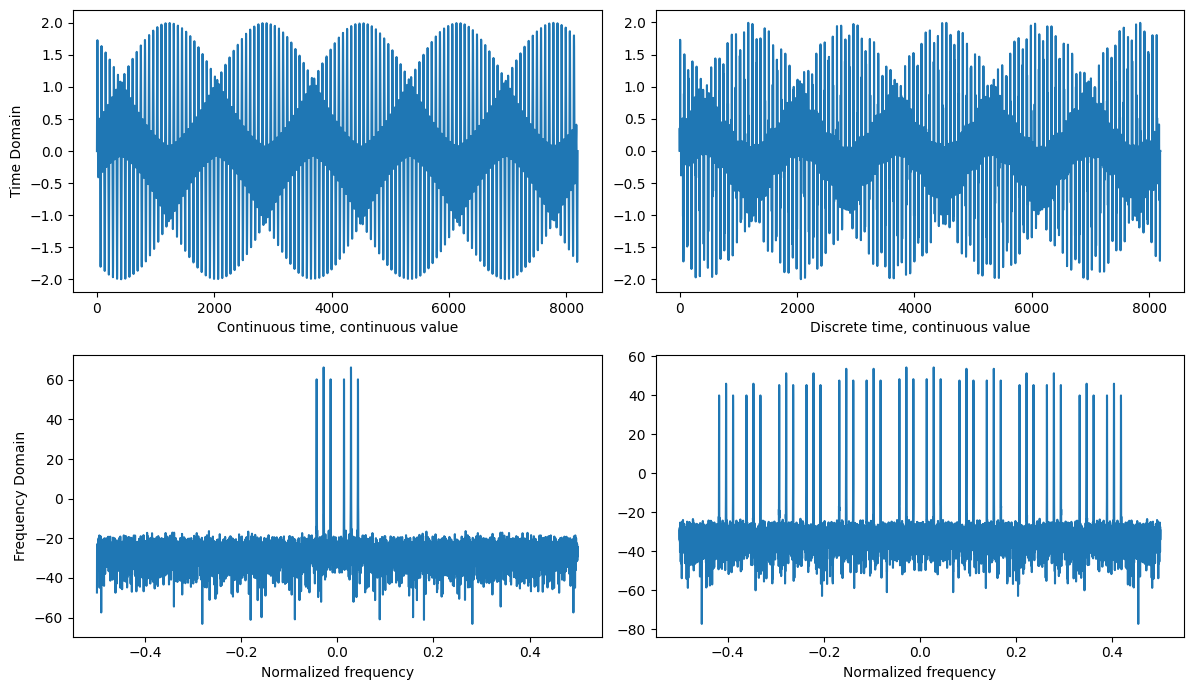

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Hann = True

#- Create a time vector
N = 2**13
t = np.linspace(0,N,N)

#- Create the "continuous time" signal with multiple sinusoidal signals and some noise
f1 = 233/N
fd = 1/N*119
x_c = np.sin(2*np.pi*f1*t) + 1/1024*np.random.randn(N) +   0.5*np.sin(2*np.pi*(f1-fd)*t) + 0.5*np.sin(2*np.pi*(f1+fd)*t)

#- Create the sampling vector, and the sampled signal
t_s_unit = [1,1,0,0,0,0,0,0]
t_s = np.tile(t_s_unit,int(N/len(t_s_unit)))
x_s = x_c*t_s

#- Convert to frequency domain with a Hanning window to avoid FFT bin energy spread
if(Hann):
    w = np.hanning(N+1)
else:
    w = np.ones(N+1)

#- Do The FFTs
X_c = np.fft.fftshift(np.fft.fft(np.multiply(w[0:N],x_c)))
X_s = np.fft.fftshift(np.fft.fft(np.multiply(w[0:N],x_s)))
freq = np.fft.fftfreq(len(t), d=t[1] - t[0])
freq_shifted = np.fft.fftshift(freq)

#- Plot
fig, axs = plt.subplots(2, 2, figsize=(12, 7))
axs[0, 0].plot(x_c)
axs[0, 0].set_ylabel("Time Domain")
axs[0, 0].set_xlabel("Continuous time, continuous value")

axs[0, 1].plot(x_s)
axs[1, 0].set_ylabel("Frequency Domain")
axs[0, 1].set_xlabel("Discrete time, continuous value")

axs[1, 0].plot(freq_shifted, 20 * np.log10(np.abs(X_c)))
axs[1, 1].plot(freq_shifted, 20 * np.log10(np.abs(X_s)))
axs[1, 0].set_xlabel("Normalized frequency")
axs[1, 1].set_xlabel("Normalized frequency")

#axs[1, 0].set_xlim(0.02, 0.035)
#axs[1, 1].set_xlim(0.02, 0.035)

plt.tight_layout()
plt.show()

## How sampling creates copies of the input spectrum

**Sampling** means recording a continuous-time signal at discrete time instants. Mathematically, we multiply the signal \(x(t)\) by a *sampling train* (a periodic sequence of impulses). In the frequency domain, multiplication in time becomes **convolution** of the Fourier transforms. The spectrum of a periodic impulse train is itself a periodic impulse train (with spacing equal to the sampling frequency \(f_s\)). Convolving the signal’s spectrum with this train therefore **replicates** the spectrum at integer multiples of \(f_s\).

So:

- The **original baseband spectrum** is repeated at \(0,\, \pm f_s,\, \pm 2f_s,\, \ldots\).
- If the signal is **bandlimited** to less than \(f_s/2\) (the [Nyquist frequency](https://en.wikipedia.org/wiki/Nyquist_frequency)), these copies do not overlap. We can recover the signal with an ideal low-pass filter (see the [Nyquist–Shannon sampling theorem](https://en.wikipedia.org/wiki/Nyquist%E2%80%93Shannon_sampling_theorem)).
- If the signal has content **above** \(f_s/2\), the copies overlap and **aliasing** occurs: high frequencies are folded back and appear as lower frequencies. The signal cannot be reconstructed exactly.

In this demo we use a **reduced effective sampling rate** (by keeping only 2 of every 8 samples). That corresponds to a lower \(f_s\), so the spectral copies are closer together. In the zoomed frequency plot you can see the **replicated** spectrum: the same pattern (main tone and sidebands) appears at the baseband and at the sampling rate and its harmonics. The Hann window is used to reduce FFT bin spreading so these replications are easier to see.

**References:**

- [Sampling (signal processing)](https://en.wikipedia.org/wiki/Sampling_(signal_processing))
- [Nyquist–Shannon sampling theorem](https://en.wikipedia.org/wiki/Nyquist%E2%80%93Shannon_sampling_theorem)
- [Aliasing](https://en.wikipedia.org/wiki/Aliasing)
- [Discrete-time Fourier transform](https://en.wikipedia.org/wiki/Discrete-time_Fourier_transform)